In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Conv2D,MaxPooling2D,Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
(x_train,y_train),(x_test,y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [3]:
x_train.shape

(50000, 32, 32, 3)

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
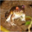

In [4]:
x_train[0]

In [5]:
y_train= y_train.flatten()
y_test = y_test.flatten()

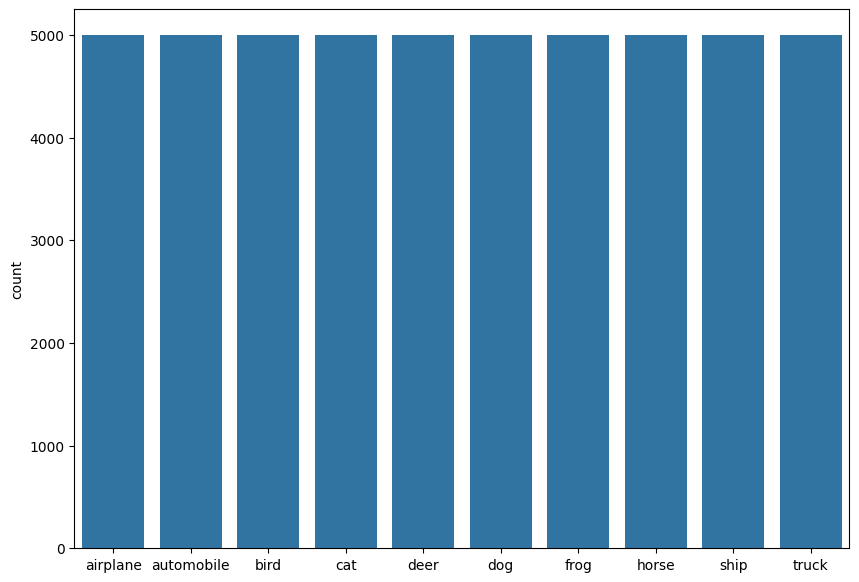

In [6]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,7))
p = sns.countplot(x=y_train)
p.set_xticks(range(len(classes)))
p.set_xticklabels(classes)
plt.show() # Add this to display the plot

In [7]:
np.isnan(x_train).any()

np.False_

In [8]:
np.isnan(x_test).any()

np.False_

In [9]:
x_train=x_train / 255.0
x_test=x_test / 255.0

In [10]:
x_train[0].shape

(32, 32, 3)

In [11]:
y_train_encoded = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test_encoded = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [12]:
print(y_train_encoded.shape)
print(y_test_encoded.shape)
print(y_test_encoded[0])
print(y_test[0])

(50000, 10)
(10000, 10)
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
3


[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


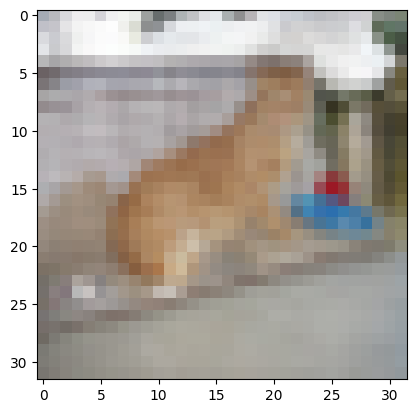

In [13]:
plt.imshow(x_train[1030])
print(y_train_encoded[1030])

In [14]:
model = Sequential([
    Conv2D(32,3,padding='same',activation='relu',input_shape=(32,32,3)),
    Conv2D(32,3,padding='same',activation='relu'),

    MaxPooling2D(),
    Dropout(0.25),
    Conv2D(64,3,padding='same',activation='relu'),
    Conv2D(64,3,padding='same',activation='relu'),

    MaxPooling2D(),
    Dropout(0.25),
    Conv2D(32,3,padding='same',activation='relu'),
    Flatten(),

    Dense(512,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(
    optimizer ='adam',
    loss="categorical_crossentropy",
    metrics = ['accuracy']
)

In [22]:
ear_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [23]:
his = model.fit(
    x_train,y_train_encoded,  # Use the one-hot encoded target variable
    epochs=100,
    validation_split=0.2,
    callbacks=[ear_stop]
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8306 - loss: 0.4870 - val_accuracy: 0.7753 - val_loss: 0.7244
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.8405 - loss: 0.4534 - val_accuracy: 0.7609 - val_loss: 0.7412
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8470 - loss: 0.4384 - val_accuracy: 0.7727 - val_loss: 0.7573
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8535 - loss: 0.4170 - val_accuracy: 0.7717 - val_loss: 0.7624
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8507 - loss: 0.4277 - val_accuracy: 0.7664 - val_loss: 0.7832
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8522 - loss: 0.4208 - val_accuracy: 0.7722 - val_loss: 0.7639
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8593 - loss: 0.4004 - val_accuracy: 0.7704 - val_loss: 0.7676
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8601 - lo

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=classes))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Accuracy: 0.7645
Classification Report:
              precision    recall  f1-score   support

    airplane       0.80      0.80      0.80      1000
  automobile       0.91      0.86      0.89      1000
        bird       0.66      0.67      0.67      1000
         cat       0.59      0.54      0.57      1000
        deer       0.73      0.70      0.72      1000
         dog       0.65      0.70      0.67      1000
        frog       0.73      0.89      0.80      1000
       horse       0.87      0.77      0.82      1000
        ship       0.89      0.85      0.87      1000
       truck       0.84      0.86      0.85      1000

    accuracy                           0.76     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.77      0.76      0.76     10000

Confusion Matrix:
[[795  14  56  12  15  12   9   6  48  33]
 [ 13 862   7   6   6   4  12   1  17  72]
 [ 45   0 672  45  68  66  77  17   5   5]
 [ 13   2  71

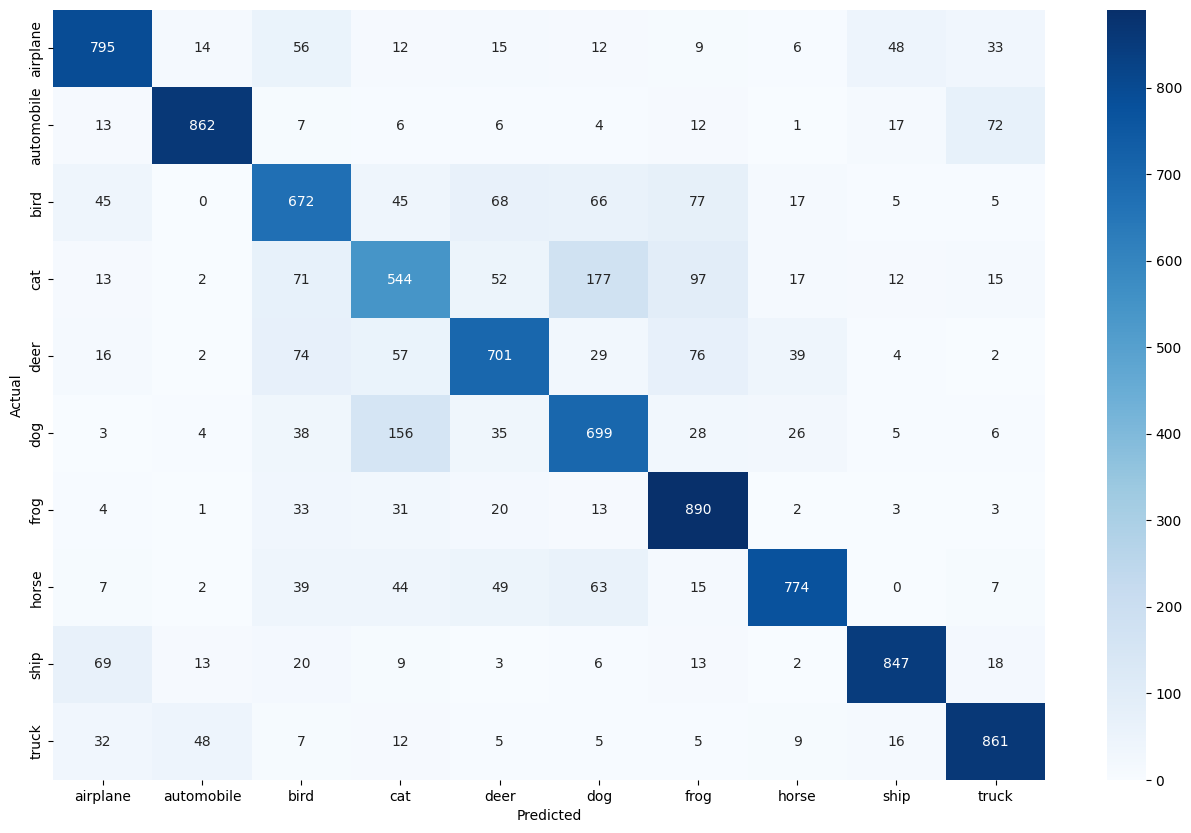

In [28]:
plt.figure(figsize=(16, 10))
c = sns.heatmap(confusion_matrix(y_test, y_pred_classes) , annot=True, fmt='d', cmap='Blues')
c.set_xlabel('Predicted')
c.set_ylabel('Actual')
c.yaxis.set_ticklabels(classes)
c.xaxis.set_ticklabels(classes)
plt.show()